In [ ]:
import xarray as xr

# Open the dataset
ds = xr.open_dataset("s2s_reforecast_sorted.nc")

# Remove the first step (index 0) from the dataset
ds_filtered = ds.isel(step=slice(1, None))

# You can check the new step values to confirm step 0 is gone
print("Remaining steps:", ds_filtered.step.values)

# If you want to check the precipitation values again for the first 10 dates (now starting at what was previously step 1)
tp_subset = ds_filtered['total_precipitation'].isel(time=slice(0, 10), step=0)
tp_values = tp_subset.values
print("Non-NaN values at new first step:")
print(tp_values[~np.isnan(tp_values)])


In [ ]:
ds.to_netcdf('s2s_reforecast_final.nc')

In [ ]:
# %% [markdown]
# # Probabilistic (tercile) dual-encoder — LAG-FREE
#
# All lag machinery removed: no LAG_DAYS, no _build_lag_index, no _assemble,
# no mixer, no lag axis in the cache. XA is plain (N, V, h, w).
#
# Built on the OLD, VERIFIED-WORKING implementations of _clim_grid and
# anomalise (the ones behind the +0.019 fold-0 result), NOT the refactored
# row-chunked versions — those are where the unexplained -0.086 regression
# lives, and there is no reason to inherit it.
#
# TWO HEADS:
#   tercile  (3 logits)  -> cross-entropy, scored by RPSS. The field-standard
#                           metric; what Horat & Lerch and the India U-Net
#                           paper report, so it is the only route to an
#                           external benchmark.
#   determ.  (1 value)   -> masked MSE, scored by skill/ACC. Keeps your mm/day
#                           product and stays comparable to every run so far.
#
# WHY PROBABILISTIC AT ALL: your shrinkage diagnostic showed std_ratio
# 0.15-0.33. That is not a flaw — for a forecast with correlation r the
# RMSE-optimal amplitude IS r x observed, so at ACC 0.15 the optimal
# deterministic prediction is nearly flat. MSE gave skill but no amplitude;
# the composite loss gave amplitude but negative skill. There is no good
# deterministic point on that frontier. A distribution does not have to pick
# a value, so "60% chance above normal" stays useful at ACC 0.15.
#
# CELLS THAT CHANGE: 1, 3, 4, 5, 6, 7, 8. Cells 9/10/11 need small edits
# (see cells_prob_9_11.py).


In [2]:
import sys
sys.path.append("..")
from scripts.xarray_utils import (
    analyze_netcdf,
    zarr_to_netcdf,
    find_missing_days,
)
import pandas as pd
import xarray as xr
ds_big = xr.open_zarr("/Users/abhimanyu/Downloads/IFS_reforecast_download-main/s2s_new_vars_sorted.zarr")
ds_imd = xr.open_zarr("/Users/abhimanyu/Desktop/s2s/data/raw/IMD_rainfall_0p25.zarr")
ds_imd = ds_imd.where(ds_imd != -999)
ds_ecm = xr.open_dataset('/Users/abhimanyu/Desktop/s2s/data/processed/s2s_reforecast_final.nc')

# convert lead days into timedeltas
step_td = pd.to_timedelta(ds_ecm.step.values, unit="D").to_numpy()

ds_ecmv = ds_ecm.assign_coords(
    valid_time=(("time", "step"),
                ds_ecm.time.values[:, None] + step_td[None, :])
)

In [3]:


# %%
# ============ CELL 1: CONFIG ============

import gc, json, os, time
from contextlib import contextmanager
import numpy as np

DTYPE = np.float32
IMD_TARGET_VAR = "rain"

WINDOWS   = [("week2", 8, 14), ("week3_4", 15, 28), ("week5_6", 29, 42)]
MONTHS    = None
COARSE_PAD = 3.0
CLIM_WINDOW_DAYS = 7
TEST_YEARS_N = 3

BIG_VARS = ["top_net_thermal_radiation", "geopotential_height_200",
            "geopotential_height_500", "geopotential_height_850",
            "geopotential_height_1000"]

# --- model / training ---
BASE, DROP = 24, 0.2
BATCH, EPOCHS = 16, 60
LR, WD, PATIENCE, FOLDS = 2e-4, 1e-3, 10, 5

# --- heads ---
USE_TERCILE = True       # 3-class head + cross-entropy, scored by RPSS
USE_DETERM  = True       # 1-value head + masked MSE, scored by skill/ACC
W_CE, W_MSE = 1.0, 1.0   # loss weights when both heads are on
LABEL_SMOOTH = 0.0       # try 0.05 if the tercile head overconfidently collapses

TAG = "prob" + ("_t" if USE_TERCILE else "") + ("_d" if USE_DETERM else "")
CACHE    = "unet_cache_prob"
OUT_MAPS = f"unet_{TAG}.nc"

print(f"TAG={TAG} | tercile={USE_TERCILE} determ={USE_DETERM} | months={MONTHS}")



TAG=prob_t_d | tercile=True determ=True | months=None


In [4]:

# %%
# ============ CELL 2: UTILS ============  (unchanged)

@contextmanager
def stage(name):
    print(f"[ ] {name} ...", flush=True)
    t0 = time.perf_counter()
    yield
    print(f"[x] {name}  ({time.perf_counter() - t0:.1f}s)", flush=True)


def normalize_step(ds, verbose=True):
    v = ds["step"].values
    if np.issubdtype(v.dtype, np.timedelta64):
        return ds
    mx = int(np.nanmax(v))
    u = "D" if mx <= 60 else ("h" if mx <= 24 * 60 else "s")
    if verbose:
        print(f"    step is {v.dtype} (max {mx}) -> units='{u}'")
    td = v.astype(np.int64).astype(f"timedelta64[{u}]").astype("timedelta64[ns]")
    return ds.assign_coords(step=("step", td))


def ensure_valid_time(ds):
    ds = normalize_step(ds)
    expected = ds["time"] + ds["step"]
    if "valid_time" in ds.coords:
        got = ds["valid_time"]
        if got.shape == expected.shape and (got.values == expected.values).all():
            return ds
        print("    WARNING: existing valid_time != time + step -> rebuilding")
        ds = ds.drop_vars("valid_time")
    return ds.assign_coords(valid_time=expected)


In [5]:


# %%
# ============ CELL 3: CLIMATOLOGY, ANOMALIES, TERCILES ============
# _clim_grid and anomalise_fold are the OLD verified implementations,
# character-for-character. Do not "optimise" them again without a
# side-by-side numerical check against these.

def _clim_grid(values, doys, window, cell_chunk=20000):
    """(n, ...) -> (366, ...) DOY climatology, chunked over cells only."""
    shp = values.shape[1:]
    n = len(values)
    v2 = values.reshape(n, -1)
    n_cells = v2.shape[1]
    centers = np.arange(1, 367)
    d = np.abs(doys[None, :].astype(np.int32) - centers[:, None])
    M = (np.minimum(d, 366 - d) <= window).astype(DTYPE)
    out = np.empty((366, n_cells), DTYPE)
    for a in range(0, n_cells, cell_chunk):
        b = min(a + cell_chunk, n_cells)
        blk = v2[:, a:b]
        fin = np.isfinite(blk)
        counts = M @ fin.astype(DTYPE)
        sums = M @ np.where(fin, blk, 0).astype(DTYPE)
        with np.errstate(invalid="ignore", divide="ignore"):
            out[:, a:b] = np.where(counts > 0, sums / np.maximum(counts, 1), np.nan)
        del blk, fin, counts, sums
    return out.reshape((366,) + shp)


def anomalise_fold(X, doy, tr):
    """Anomalise + standardise ONE predictor array on train-fold years only."""
    clim = _clim_grid(X[tr], doy[tr], CLIM_WINDOW_DAYS)
    A = X - clim[doy - 1]
    m = np.nanmean(A[tr], axis=(0, 2, 3), keepdims=True)
    s = np.nanstd(A[tr], axis=(0, 2, 3), keepdims=True)
    s = np.where(s < 1e-8, 1.0, s)
    return np.nan_to_num((A - m) / s).astype(DTYPE)


def anomalise_target(y, doy, tr):
    clim = _clim_grid(y[tr], doy[tr], CLIM_WINDOW_DAYS)
    return (y - clim[doy - 1]).astype(DTYPE)


def tercile_edges(ya, tr, mask, chunk=20000):
    """Per-cell 33rd/67th percentiles of the target ANOMALY, TRAIN only.

    Per-cell, not global: a global edge would put the arid northwest
    permanently in 'below normal'. Train-only for the same leakage reason as
    the climatology — edges that saw the val years inflate RPSS.
    """
    flat = ya[tr].reshape(int(np.sum(tr)), -1)
    n_cells = flat.shape[1]
    e1 = np.full(n_cells, np.nan, DTYPE)
    e2 = np.full(n_cells, np.nan, DTYPE)
    mf = mask.reshape(-1)
    for a in range(0, n_cells, chunk):
        b = min(a + chunk, n_cells)
        valid = mf[a:b]
        if not valid.any():
            continue
        sub = flat[:, a:b][:, valid]
        idx = np.where(valid)[0] + a
        with np.errstate(invalid="ignore"):
            e1[idx] = np.nanpercentile(sub, 100 / 3, axis=0)
            e2[idx] = np.nanpercentile(sub, 200 / 3, axis=0)
    return e1.reshape(mask.shape), e2.reshape(mask.shape)


def to_tercile(ya, e1, e2):
    """(N,H,W) anomalies -> (N,H,W) int64 class in {0,1,2}. NaN -> 1 (ignored
    by the masked loss anyway, but keeps the array integer)."""
    cls = np.ones(ya.shape, np.int64)
    with np.errstate(invalid="ignore"):
        cls[ya <= e1[None]] = 0
        cls[ya > e2[None]] = 2
    return cls



In [6]:


# %%
# ============ CELL 3: CLIMATOLOGY, ANOMALIES, TERCILES ============
# _clim_grid and anomalise_fold are the OLD verified implementations,
# character-for-character. Do not "optimise" them again without a
# side-by-side numerical check against these.

def _clim_grid(values, doys, window, cell_chunk=20000):
    """(n, ...) -> (366, ...) DOY climatology, chunked over cells only."""
    shp = values.shape[1:]
    n = len(values)
    v2 = values.reshape(n, -1)
    n_cells = v2.shape[1]
    centers = np.arange(1, 367)
    d = np.abs(doys[None, :].astype(np.int32) - centers[:, None])
    M = (np.minimum(d, 366 - d) <= window).astype(DTYPE)
    out = np.empty((366, n_cells), DTYPE)
    for a in range(0, n_cells, cell_chunk):
        b = min(a + cell_chunk, n_cells)
        blk = v2[:, a:b]
        fin = np.isfinite(blk)
        counts = M @ fin.astype(DTYPE)
        sums = M @ np.where(fin, blk, 0).astype(DTYPE)
        with np.errstate(invalid="ignore", divide="ignore"):
            out[:, a:b] = np.where(counts > 0, sums / np.maximum(counts, 1), np.nan)
        del blk, fin, counts, sums
    return out.reshape((366,) + shp)


def anomalise_fold(X, doy, tr):
    """Anomalise + standardise ONE predictor array on train-fold years only."""
    clim = _clim_grid(X[tr], doy[tr], CLIM_WINDOW_DAYS)
    A = X - clim[doy - 1]
    m = np.nanmean(A[tr], axis=(0, 2, 3), keepdims=True)
    s = np.nanstd(A[tr], axis=(0, 2, 3), keepdims=True)
    s = np.where(s < 1e-8, 1.0, s)
    return np.nan_to_num((A - m) / s).astype(DTYPE)


def anomalise_target(y, doy, tr):
    clim = _clim_grid(y[tr], doy[tr], CLIM_WINDOW_DAYS)
    return (y - clim[doy - 1]).astype(DTYPE)


def tercile_edges(ya, tr, mask, chunk=20000):
    """Per-cell 33rd/67th percentiles of the target ANOMALY, TRAIN only.

    Per-cell, not global: a global edge would put the arid northwest
    permanently in 'below normal'. Train-only for the same leakage reason as
    the climatology — edges that saw the val years inflate RPSS.
    """
    flat = ya[tr].reshape(int(np.sum(tr)), -1)
    n_cells = flat.shape[1]
    e1 = np.full(n_cells, np.nan, DTYPE)
    e2 = np.full(n_cells, np.nan, DTYPE)
    mf = mask.reshape(-1)
    for a in range(0, n_cells, chunk):
        b = min(a + chunk, n_cells)
        valid = mf[a:b]
        if not valid.any():
            continue
        sub = flat[:, a:b][:, valid]
        idx = np.where(valid)[0] + a
        with np.errstate(invalid="ignore"):
            e1[idx] = np.nanpercentile(sub, 100 / 3, axis=0)
            e2[idx] = np.nanpercentile(sub, 200 / 3, axis=0)
    return e1.reshape(mask.shape), e2.reshape(mask.shape)


def to_tercile(ya, e1, e2):
    """(N,H,W) anomalies -> (N,H,W) int64 class in {0,1,2}. NaN -> 1 (ignored
    by the masked loss anyway, but keeps the array integer)."""
    cls = np.ones(ya.shape, np.int64)
    with np.errstate(invalid="ignore"):
        cls[ya <= e1[None]] = 0
        cls[ya > e2[None]] = 2
    return cls


In [ ]:


# %%
# ============ CELL 4: PREPARE (lag-free) ============
# Every trace of lag machinery is gone. XA/XB are plain (N, V, h, w).

def _subset_box(ds, imd, pad):
    ds = ensure_valid_time(ds)
    for c in ("lat", "lon"):
        if ds[c].values[0] > ds[c].values[-1]:
            ds = ds.sortby(c)
    if pad is not None:
        la0, la1 = float(imd.lat.min()), float(imd.lat.max())
        lo0, lo1 = float(imd.lon.min()), float(imd.lon.max())
        ds = ds.sel(lat=slice(la0 - pad, la1 + pad), lon=slice(lo0 - pad, lo1 + pad))
    return ds


def _window_stack(sub, feature_vars, leads, lo, hi):
    from dask.diagnostics import ProgressBar
    sel = np.where((leads >= lo) & (leads <= hi))[0]
    if len(sel) == 0:
        raise ValueError(f"no leads in [{lo},{hi}]")
    with ProgressBar():
        Xw = sub.isel(step=sel).mean(dim="step").compute()
    return np.stack([Xw[v].values for v in feature_vars], axis=1).astype(DTYPE), sel


def prepare(ecmwf_ds, big_ds, imd_ds, cache_path):
    import xarray as xr
    from dask.diagnostics import ProgressBar

    imd = imd_ds[IMD_TARGET_VAR].assign_coords(
        time=imd_ds[IMD_TARGET_VAR]["time"].dt.floor("D"))
    flat_lat, flat_lon = imd["lat"].values, imd["lon"].values

    with stage("Subset both boxes"):
        subA = _subset_box(ecmwf_ds, imd, COARSE_PAD)
        subB = _subset_box(big_ds, imd, pad=None)
        varsA = list(subA.data_vars)
        missing = [v for v in BIG_VARS if v not in subB.data_vars]
        if missing:
            raise KeyError(f"BIG_VARS missing: {missing}")
        varsB = BIG_VARS
        clatA, clonA = subA["lat"].values, subA["lon"].values
        clatB, clonB = subB["lat"].values, subB["lon"].values
        leadsA = (subA["step"].values / np.timedelta64(1, "D")).astype(int)
        leadsB = (subB["step"].values / np.timedelta64(1, "D")).astype(int)
        initA, initB = subA["time"].values, subB["time"].values
        if MONTHS is not None:
            keep = np.isin(initA.astype("datetime64[M]").astype(int) % 12 + 1, MONTHS)
            subA, subB = subA.isel(time=keep), subB.isel(time=keep)
            initA = initB = initA[keep]
        print(f"    A: {len(varsA)} vars {len(clatA)}x{len(clonA)} | "
              f"B: {len(varsB)} vars {len(clatB)}x{len(clonB)} | {len(initA)} inits")

    if initA.shape != initB.shape or not (initA == initB).all():
        raise ValueError("A and B have different init dates")
    for cla, clo, nm in [(clatA, clonA, "A"), (clatB, clonB, "B")]:
        if not (cla.min() <= flat_lat.min() and cla.max() >= flat_lat.max()
                and clo.min() <= flat_lon.min() and clo.max() >= flat_lon.max()):
            raise ValueError(f"IMD grid not inside box {nm}")

    XA_l, XB_l, y_l, doy_l, wid_l = [], [], [], [], []
    for wi, (wname, lo, hi) in enumerate(WINDOWS):
        with stage(f"Window {wname} (days {lo}-{hi})"):
            blkA, sel = _window_stack(subA, varsA, leadsA, lo, hi)
            blkB, _ = _window_stack(subB, varsB, leadsB, lo, hi)
            XA_l.append(blkA); XB_l.append(blkB)
            vt = subA["valid_time"].isel(step=sel).dt.floor("D").values
            with ProgressBar():
                y_all = imd.reindex(time=vt.ravel()).astype(DTYPE).compute().values
            y_l.append(np.nanmean(y_all.reshape(vt.shape + y_all.shape[1:]), axis=1))
            del y_all
            centre = initA + np.timedelta64((lo + hi) // 2, "D")
            doy_l.append(xr.DataArray(centre, dims="t").dt.dayofyear.values)
            wid_l.append(np.full(len(initA), wi, np.int64))
            gc.collect()

    XA = np.concatenate(XA_l); del XA_l
    XB = np.concatenate(XB_l); del XB_l
    y = np.concatenate(y_l); doy = np.concatenate(doy_l); wid = np.concatenate(wid_l)
    year = np.tile(initA.astype("datetime64[Y]").astype(int) + 1970, len(WINDOWS))
    gc.collect()

    with stage("Mask + test holdout + cache"):
        mask = np.isfinite(y).all(axis=0)
        uy = np.unique(year)
        is_test = np.isin(year, list(uy[-TEST_YEARS_N:]))
        print(f"    XA {XA.shape} {XA.nbytes/1e9:.2f} GB | XB {XB.shape} "
              f"{XB.nbytes/1e9:.2f} GB | mask {int(mask.sum())} cells")
        print(f"    test years {sorted(uy[-TEST_YEARS_N:])}")
        os.makedirs(cache_path, exist_ok=True)
        np.save(f"{cache_path}/XA.npy", XA)
        np.save(f"{cache_path}/XB.npy", XB)
        np.save(f"{cache_path}/y.npy", y)
        np.savez(f"{cache_path}/meta.npz", doy=doy, wid=wid, year=year,
                 mask=mask, is_test=is_test, clatA=clatA, clonA=clonA,
                 clatB=clatB, clonB=clonB, flat_lat=flat_lat, flat_lon=flat_lon,
                 varsA=np.array(varsA), varsB=np.array(varsB),
                 window_names=np.array([w[0] for w in WINDOWS]))
        tot = sum(os.path.getsize(f"{cache_path}/{f}") for f in os.listdir(cache_path))
        print(f"    {tot/1e9:.2f} GB -> {cache_path}/")


# RUN ONCE:
prepare(ds_ecmv, ds_big, ds_imd, CACHE)



In [8]:
# %%
# ============ CELL 5: LOAD CACHE + GRIDS + DATASET ============

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

DEV = ("cuda" if torch.cuda.is_available()
       else "mps" if torch.backends.mps.is_available() else "cpu")

XA = np.load(f"{CACHE}/XA.npy")
XB = np.load(f"{CACHE}/XB.npy")
y  = np.load(f"{CACHE}/y.npy")
_m = np.load(f"{CACHE}/meta.npz")

doy, wid = np.asarray(_m["doy"]), np.asarray(_m["wid"])
year, mask, is_test = np.asarray(_m["year"]), np.asarray(_m["mask"]), np.asarray(_m["is_test"])
flat_lat, flat_lon = np.asarray(_m["flat_lat"]), np.asarray(_m["flat_lon"])
clatA, clonA, clatB, clonB = _m["clatA"], _m["clonA"], _m["clatB"], _m["clonB"]
window_names = [str(w) for w in _m["window_names"]]

H, W = len(flat_lat), len(flat_lon)
N_WIN = len(window_names)
C_A, C_B = XA.shape[1], XB.shape[1]      # no lag axis


def _make_samp(clat, clon):
    gy = 2 * (flat_lat - clat[0]) / (clat[-1] - clat[0]) - 1
    gx = 2 * (flat_lon - clon[0]) / (clon[-1] - clon[0]) - 1
    gyy, gxx = np.meshgrid(gy, gx, indexing="ij")
    s = np.stack([gxx, gyy], -1).astype(np.float32)[None]
    assert np.abs(s).max() <= 1.0, "fine grid outside source box"
    return torch.tensor(s).to(DEV)


SAMP_A, SAMP_B = _make_samp(clatA, clonA), _make_samp(clatB, clonB)
_lat2 = (flat_lat[:, None] - flat_lat.mean()) / flat_lat.std()
_lon2 = (flat_lon[None, :] - flat_lon.mean()) / flat_lon.std()
STATIC = torch.tensor(np.stack([
    mask.astype(DTYPE),
    np.broadcast_to(_lat2, (H, W)).astype(DTYPE),
    np.broadcast_to(_lon2, (H, W)).astype(DTYPE)])[None]).to(DEV)


class S2SDS(Dataset):
    """Yields (xa, xb, wid, y_anom, y_class, mask). Per-sample fin, matching
    the old working code — not a precomputed constant."""
    def __init__(self, XAa, XBa, ya, ycls, idx):
        self.XAa, self.XBa, self.ya, self.ycls, self.idx = XAa, XBa, ya, ycls, idx

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, i):
        j = self.idx[i]
        fin = (np.isfinite(self.ya[j]) & mask).astype(DTYPE)
        return (torch.from_numpy(self.XAa[j]),
                torch.from_numpy(self.XBa[j]),
                int(wid[j]),
                torch.from_numpy(np.nan_to_num(self.ya[j])),
                torch.from_numpy(self.ycls[j]),
                torch.from_numpy(fin))


print(f"device {DEV} | {len(XA)} samples | encA {C_A}ch encB {C_B}ch | "
      f"grid {H}x{W} | {int(mask.sum())} valid cells")

device mps | 11160 samples | encA 21ch encB 5ch | grid 129x135 | 4964 valid cells


In [9]:
# %%
# ============ CELL 6: MODEL (two heads) ============
# Same dual-encoder trunk as the +0.019 run. Only the head changes:
#   head_t: 3 logits -> tercile probabilities
#   head_d: 1 value  -> deterministic anomaly (mm/day), unchanged from before
# Both share the trunk, so the tercile task regularises the deterministic one
# and vice versa. Set either to None in cell 1 to run single-head.

def gn(c):
    for g in (8, 4, 2, 1):
        if c % g == 0:
            return nn.GroupNorm(g, c)


class Block(nn.Module):
    def __init__(self, ci, co, drop=0.0):
        super().__init__()
        L = [nn.Conv2d(ci, co, 3, padding=1), gn(co), nn.SiLU(),
             nn.Conv2d(co, co, 3, padding=1), gn(co), nn.SiLU()]
        if drop > 0:
            L.append(nn.Dropout2d(drop))
        self.f = nn.Sequential(*L)

    def forward(self, x):
        return self.f(x)


class DualUNet(nn.Module):
    """Two coarse encoders on different boxes, each grid_sampled to the shared
    fine grid with its own sampling grid, concatenated there, one decoder,
    two heads."""
    def __init__(self, cA, cB, n_win, base=24, drop=0.2, emb=4,
                 tercile=True, determ=True):
        super().__init__()
        self.emb = nn.Embedding(n_win, emb)
        self.encA1 = Block(cA + emb, base * 2); self.encA2 = Block(base * 2, base * 2)
        self.encB1 = Block(cB, base * 2);       self.encB2 = Block(base * 2, base * 2)
        self.inp = Block(base * 4 + 3, base)
        self.d1 = Block(base, base * 2, drop)
        self.d2 = Block(base * 2, base * 4, drop)
        self.bott = Block(base * 4, base * 4, drop)
        self.u2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.du2 = Block(base * 4, base * 2, drop)
        self.u1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.du1 = Block(base * 2, base)
        self.head_t = nn.Conv2d(base, 3, 1) if tercile else None
        self.head_d = nn.Conv2d(base, 1, 1) if determ else None
        self.pool = nn.MaxPool2d(2)

    def forward(self, xa, xb, w, sampA, sampB, static):
        b = xa.shape[0]
        e = self.emb(w)[:, :, None, None].expand(-1, -1, xa.shape[2], xa.shape[3])
        ca = self.encA2(self.encA1(torch.cat([xa, e], 1)))
        cb = self.encB2(self.encB1(xb))
        fa = F.grid_sample(ca, sampA.expand(b, -1, -1, -1),
                           mode="bilinear", align_corners=True)
        fb = F.grid_sample(cb, sampB.expand(b, -1, -1, -1),
                           mode="bilinear", align_corners=True)
        f = torch.cat([fa, fb, static.expand(b, -1, -1, -1)], 1)
        H0, W0 = f.shape[-2:]
        f = F.pad(f, (0, (-W0) % 4, 0, (-H0) % 4), mode="replicate")
        e0 = self.inp(f)
        e1 = self.d1(self.pool(e0))
        e2 = self.d2(self.pool(e1))
        u = self.du2(torch.cat([self.u2(self.bott(e2)), e1], 1))
        u = self.du1(torch.cat([self.u1(u), e0], 1))
        u = u[:, :, :H0, :W0]
        logits = self.head_t(u) if self.head_t is not None else None      # (B,3,H,W)
        det = self.head_d(u).squeeze(1) if self.head_d is not None else None
        return logits, det


def new_model():
    return DualUNet(C_A, C_B, N_WIN, base=BASE, drop=DROP,
                    tercile=USE_TERCILE, determ=USE_DETERM).to(DEV)


print(f"params: {sum(p.numel() for p in new_model().parameters())/1e6:.2f}M")

params: 0.59M


In [12]:


# %%
# ============ CELL 7: LOSS ============
# Cross-entropy on terciles + masked MSE on the deterministic head.
# Both normalised BY THE MASK, never by numel.

def combined_loss(logits, det, y_cls, y_anom, m):
    total, stats = 0.0, {}
    if logits is not None:
        # per-cell CE, then mask. reduction='none' so we can weight by mask.
        ce = F.cross_entropy(logits, y_cls, reduction="none",
                             label_smoothing=LABEL_SMOOTH)          # (B,H,W)
        ce = (ce * m).sum() / m.sum().clamp(min=1.0)
        total = total + W_CE * ce
        stats["ce"] = float(ce.detach())
    if det is not None:
        mse = ((det - y_anom) ** 2 * m).sum() / m.sum().clamp(min=1.0)
        total = total + W_MSE * mse
        stats["mse"] = float(mse.detach())
    return total, stats


In [13]:


# %%
# ============ CELL 8: METRICS (RPSS + skill/ACC) ============

def rps(probs, obs_cls, n_cat=3):
    """Ranked probability score, per (sample, cell).

    RPS = sum_k (CDF_forecast_k - CDF_obs_k)^2, summed over the first K-1
    categories (the last term is identically zero). Lower is better.
    probs: (N,3,H,W) already softmaxed. obs_cls: (N,H,W) ints.
    """
    cdf_f = np.cumsum(probs, axis=1)                       # (N,3,H,W)
    onehot = np.eye(n_cat, dtype=DTYPE)[obs_cls]           # (N,H,W,3)
    cdf_o = np.cumsum(np.moveaxis(onehot, -1, 1), axis=1)  # (N,3,H,W)
    return ((cdf_f - cdf_o) ** 2)[:, :n_cat - 1].sum(axis=1)   # (N,H,W)


def rpss_map(probs, obs_cls, fin, n_cat=3):
    """RPSS vs an equiprobable climatological forecast (1/3,1/3,1/3), per cell.

    Climatology is the honest reference here for the same reason zero-anomaly
    was for the deterministic head: it is what you get from knowing only the
    calendar. RPSS > 0 means the forecast beats that.
    """
    clim = np.full_like(probs, 1.0 / n_cat)
    r_f = np.where(fin, rps(probs, obs_cls, n_cat), np.nan)
    r_c = np.where(fin, rps(clim, obs_cls, n_cat), np.nan)
    with np.errstate(invalid="ignore", divide="ignore"):
        mf = np.nanmean(r_f, axis=0)
        mc = np.nanmean(r_c, axis=0)
        ok = mc > 1e-9
        return np.where(ok, 1 - mf / np.where(ok, mc, 1), np.nan)


def skill_acc(p, t, fin):
    """Deterministic head: per-cell skill vs zero-anomaly climatology, and ACC."""
    se_m = np.where(fin, (t - p) ** 2, np.nan)
    se_c = np.where(fin, t ** 2, np.nan)
    with np.errstate(invalid="ignore"):
        rm = np.sqrt(np.nanmean(se_m, axis=0))
        rc = np.sqrt(np.nanmean(se_c, axis=0))
        ok = rc > 1e-6
        skill = np.where(ok, 1 - rm / np.where(ok, rc, 1), np.nan)
        tm = np.nanmean(np.where(fin, t, np.nan), axis=0)
        pm = np.nanmean(np.where(fin, p, np.nan), axis=0)
        num = np.nansum(np.where(fin, (t - tm) * (p - pm), np.nan), axis=0)
        den = np.sqrt(np.nansum(np.where(fin, (t - tm) ** 2, np.nan), axis=0)
                      * np.nansum(np.where(fin, (p - pm) ** 2, np.nan), axis=0))
        acc = np.where(den > 0, num / den, np.nan)
    return skill, acc


def std_ratio(p, t, fin):
    pv, tv = p[fin], t[fin]
    return float(pv.std() / tv.std()) if tv.std() > 0 else np.nan

In [19]:



# %%
# ============ CELL 9: TRAIN / PREDICT ============

def train_one(tr_idx, va_idx, XAa, XBa, ya, ycls, max_epochs=EPOCHS, verbose=False):
    tr_dl = DataLoader(S2SDS(XAa, XBa, ya, ycls, tr_idx), batch_size=BATCH, shuffle=True)
    va_dl = DataLoader(S2SDS(XAa, XBa, ya, ycls, va_idx), batch_size=BATCH, shuffle=False)

    model = new_model()
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)
    best, best_state, wait = np.inf, None, 0

    for ep in range(max_epochs):
        model.train()
        for xa, xb, w, ya_b, yc_b, mb in tr_dl:
            xa, xb, w = xa.to(DEV), xb.to(DEV), w.to(DEV)
            ya_b, yc_b, mb = ya_b.to(DEV), yc_b.to(DEV), mb.to(DEV)
            logits, det = model(xa, xb, w, SAMP_A, SAMP_B, STATIC)
            loss, _ = combined_loss(logits, det, yc_b, ya_b, mb)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
        sched.step()

        model.eval()
        vl, n, st = 0.0, 0, {}
        with torch.no_grad():
            for xa, xb, w, ya_b, yc_b, mb in va_dl:
                xa, xb, w = xa.to(DEV), xb.to(DEV), w.to(DEV)
                ya_b, yc_b, mb = ya_b.to(DEV), yc_b.to(DEV), mb.to(DEV)
                logits, det = model(xa, xb, w, SAMP_A, SAMP_B, STATIC)
                l, st = combined_loss(logits, det, yc_b, ya_b, mb)
                vl += float(l) * len(xa); n += len(xa)
        vl /= n

        if vl < best - 1e-6:
            best, wait = vl, 0
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}
        else:
            wait += 1
        if verbose:
            print(f"      ep {ep:>2} vloss {vl:.4f} " +
                  " ".join(f"{k} {v:.4f}" for k, v in st.items()), flush=True)
        if wait >= PATIENCE:
            break

    model.load_state_dict(best_state)
    return model, best, ep + 1


def predict(model, idx, XAa, XBa, ya, ycls):
    """Returns (probs (n,3,H,W) or None, det (n,H,W) or None)."""
    dl = DataLoader(S2SDS(XAa, XBa, ya, ycls, idx), batch_size=BATCH, shuffle=False)
    P, D = [], []
    model.eval()
    with torch.no_grad():
        for xa, xb, w, _, _, _ in dl:
            logits, det = model(xa.to(DEV), xb.to(DEV), w.to(DEV),
                                SAMP_A, SAMP_B, STATIC)
            if logits is not None:
                P.append(F.softmax(logits, dim=1).cpu().numpy())
            if det is not None:
                D.append(det.cpu().numpy())
    return (np.concatenate(P) if P else None,
            np.concatenate(D) if D else None)


In [20]:


# %%
# ============ CELL 10: CV RUNNER ============

def run_fold(tr_i, va_i):
    XAa = anomalise_fold(XA, doy, tr_i)
    XBa = anomalise_fold(XB, doy, tr_i)
    ya = anomalise_target(y, doy, tr_i)
    e1, e2 = tercile_edges(ya, tr_i, mask)          # train-only edges
    ycls = to_tercile(ya, e1, e2)

    model, vloss, eps = train_one(np.where(tr_i)[0], np.where(va_i)[0],
                                  XAa, XBa, ya, ycls)
    probs, det = predict(model, np.where(va_i)[0], XAa, XBa, ya, ycls)

    fin = np.isfinite(np.asarray(y)[va_i]) & mask[None]
    res = dict(epochs=int(eps), vloss=float(vloss))
    if probs is not None:
        r = rpss_map(probs, ycls[va_i], fin)
        res["rpss"] = float(np.nanmean(r[mask]))
        res["rpss_pos"] = float(100 * np.nanmean(r[mask] > 0))
    if det is not None:
        sk, ac = skill_acc(det, ya[va_i], fin)
        res["skill"] = float(np.nanmean(sk[mask]))
        res["acc"] = float(np.nanmean(ac[mask]))
        res["std_ratio"] = std_ratio(det, ya[va_i], fin)
    del XAa, XBa, ya, ycls, model, probs, det; gc.collect()
    return res


resume_path = OUT_MAPS.replace(".nc", "_folds.json")
done = {}
if os.path.exists(resume_path):
    done = {int(k): v for k, v in json.load(open(resume_path)).items()}
    print(f"resuming: folds {sorted(done)} cached")

nontest_years = sorted(set(year[~is_test].tolist()))
blocks = np.array_split(nontest_years, FOLDS)

with stage(f"[{TAG}] CV: {FOLDS} folds over {len(nontest_years)} years"):
    for fi, vy_arr in enumerate(blocks):
        if fi in done:
            r = done[fi]
            print(f"  fold {fi} (cached): " +
                  " | ".join(f"{k} {v:+.4f}" for k, v in r.items()
                             if isinstance(v, float)))
            continue
        vy = set(vy_arr.tolist())
        va_i = np.isin(year, list(vy)) & ~is_test
        tr_i = ~np.isin(year, list(vy)) & ~is_test
        r = run_fold(tr_i, va_i)
        r["val_years"] = sorted(vy)
        done[fi] = r
        json.dump({str(k): v for k, v in done.items()}, open(resume_path, "w"), indent=2)
        msg = f"  fold {fi} val {sorted(vy)}:"
        if "rpss" in r:
            msg += f" RPSS {r['rpss']:+.4f} ({r['rpss_pos']:.0f}% cells+)"
        if "skill" in r:
            msg += f" | skill {r['skill']:+.3f} ACC {r['acc']:.3f} std {r['std_ratio']:.3f}"
        print(msg + f" | {r['epochs']} ep  [saved]", flush=True)

    ks = [i for i in range(FOLDS) if i in done]
    for key in ("rpss", "skill", "acc"):
        vals = [done[i][key] for i in ks if key in done[i]]
        if vals:
            print(f"\n  [{TAG}] CV {key:>5}: {np.mean(vals):+.4f} +/- {np.std(vals):.4f}")

[ ] [prob_t_d] CV: 5 folds over 17 years ...


/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_64872/4130821505.py:28: RuntimeWarning: Mean of empty slice
  mf = np.nanmean(r_f, axis=0)
/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_64872/4130821505.py:29: RuntimeWarning: Mean of empty slice
  mc = np.nanmean(r_c, axis=0)
/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_64872/4130821505.py:39: RuntimeWarning: Mean of empty slice
  rm = np.sqrt(np.nanmean(se_m, axis=0))
/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_64872/4130821505.py:40: RuntimeWarning: Mean of empty slice
  rc = np.sqrt(np.nanmean(se_c, axis=0))
/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_64872/4130821505.py:43: RuntimeWarning: Mean of empty slice
  tm = np.nanmean(np.where(fin, t, np.nan), axis=0)
/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_64872/4130821505.py:44: RuntimeWarning: Mean of empty slice
  pm = np.nanmean(np.where(fin, p, np.nan), axis=0)


  fold 0 val [2005, 2006, 2007, 2008]: RPSS +0.1154 (99% cells+) | skill +0.022 ACC 0.241 std 0.279 | 18 ep  [saved]
  fold 1 val [2009, 2010, 2011, 2012]: RPSS +0.1086 (97% cells+) | skill +0.028 ACC 0.240 std 0.264 | 22 ep  [saved]
  fold 2 val [2013, 2014, 2015]: RPSS +0.1237 (99% cells+) | skill +0.023 ACC 0.253 std 0.324 | 17 ep  [saved]
  fold 3 val [2016, 2017, 2018]: RPSS +0.1003 (96% cells+) | skill +0.030 ACC 0.241 std 0.271 | 25 ep  [saved]
  fold 4 val [2019, 2020, 2021]: RPSS +0.0824 (97% cells+) | skill +0.027 ACC 0.243 std 0.237 | 14 ep  [saved]

  [prob_t_d] CV  rpss: +0.1061 +/- 0.0141

  [prob_t_d] CV skill: +0.0258 +/- 0.0029

  [prob_t_d] CV   acc: +0.2434 +/- 0.0047
[x] [prob_t_d] CV: 5 folds over 17 years  (16501.3s)


In [21]:
# %%
# ============ CELL 10b: FINAL MODEL -> TEST ============
# Saves everything an operational forecast would need: weights, the tercile
# edges (to translate bucket -> mm/day), and both heads' predictions.

with stage("Final model on all non-test years -> test"):
    es_years = set(nontest_years[-2:])           # early-stopping slice only
    va_i = np.isin(year, list(es_years)) & ~is_test
    fit_i = (~is_test) & ~va_i

    XAa = anomalise_fold(XA, doy, fit_i)
    XBa = anomalise_fold(XB, doy, fit_i)
    ya = anomalise_target(y, doy, fit_i)
    e1, e2 = tercile_edges(ya, fit_i, mask)      # fit-years only
    ycls = to_tercile(ya, e1, e2)

    model, _, eps = train_one(np.where(fit_i)[0], np.where(va_i)[0],
                              XAa, XBa, ya, ycls)
    te_i = np.where(is_test)[0]
    probs, det = predict(model, te_i, XAa, XBa, ya, ycls)

    t_anom = ya[is_test]
    t_cls = ycls[is_test]
    fin = np.isfinite(np.asarray(y)[is_test]) & mask[None]
    wid_te = wid[is_test]
    print(f"  trained {eps} ep")

    # --- sanity: are the tercile buckets balanced on TEST data? ---
    # Edges came from fit years. If test years were unusually wet/dry the
    # classes skew, and RPSS can be flattered by the model just learning to
    # name the common bucket. Want ~0.33 each.
    frac = [float((t_cls[:, mask] == k).mean()) for k in range(3)]
    print(f"  test class balance: dry {frac[0]:.3f} | normal {frac[1]:.3f} | "
          f"wet {frac[2]:.3f}   (want ~0.333 each)")
    if max(frac) - min(frac) > 0.08:
        print("  >>> WARNING: buckets are skewed; interpret RPSS with care.")

    import xarray as xr
    dvars, summary = {}, {}
    for w in range(N_WIN):
        sm = wid_te == w
        if sm.sum() == 0:
            continue
        wn = window_names[w]
        s = {}
        if probs is not None:
            r = rpss_map(probs[sm], t_cls[sm], fin[sm])
            dvars[f"{wn}_rpss"] = (("lat", "lon"), r)
            s["rpss"] = float(np.nanmean(r[mask]))
            s["rpss_pos"] = float(100 * np.nanmean(r[mask] > 0))
        if det is not None:
            sk, ac = skill_acc(det[sm], t_anom[sm], fin[sm])
            dvars[f"{wn}_skill"] = (("lat", "lon"), sk)
            dvars[f"{wn}_acc"] = (("lat", "lon"), ac)
            s["skill"] = float(np.nanmean(sk[mask]))
            s["acc"] = float(np.nanmean(ac[mask]))
            s["std_ratio"] = std_ratio(det[sm], t_anom[sm], fin[sm])
        summary[wn] = s
        msg = f"  test {wn:>8}:"
        if "rpss" in s:
            msg += f" RPSS {s['rpss']:+.4f} ({s['rpss_pos']:.0f}% cells+)"
        if "skill" in s:
            msg += f" | skill {s['skill']:+.4f} ACC {s['acc']:.4f} std {s['std_ratio']:.3f}"
        print(msg)

    xr.Dataset(dvars, coords={"lat": flat_lat, "lon": flat_lon}).to_netcdf(OUT_MAPS)

    # probs is (n,3,H,W) — the biggest artifact here, keep it compressed
    np.savez_compressed(OUT_MAPS.replace(".nc", "_pred.npz"),
                        probs=probs if probs is not None else np.zeros(0),
                        det=det if det is not None else np.zeros(0),
                        obs_anom=t_anom, obs_cls=t_cls, wid=wid_te,
                        e1=e1, e2=e2)          # edges: bucket -> mm/day
    torch.save({"state": model.state_dict(), "tag": TAG,
                "e1": e1, "e2": e2}, OUT_MAPS.replace(".nc", ".pt"))

    # --- running comparison across experiments ---
    ks = [i for i in range(FOLDS) if i in done]
    cv = {k: float(np.mean([done[i][k] for i in ks if k in done[i]]))
          for k in ("rpss", "skill", "acc") if any(k in done[i] for i in ks)}
    cv_sd = {k: float(np.std([done[i][k] for i in ks if k in done[i]]))
             for k in cv}
    tbl = "experiments.json"
    allr = json.load(open(tbl)) if os.path.exists(tbl) else {}
    allr[TAG] = dict(cv=cv, cv_sd=cv_sd, test=summary, months=str(MONTHS),
                     tercile=USE_TERCILE, determ=USE_DETERM, base=BASE,
                     w_ce=W_CE, w_mse=W_MSE)
    json.dump(allr, open(tbl, "w"), indent=2)
    print(f"  -> {OUT_MAPS} (+ _pred.npz, .pt); appended to {tbl}")

print(f"\n{'experiment':>18} {'CV RPSS':>9} {'CV ACC':>8} {'w3_4 RPSS':>10} "
      f"{'w3_4 ACC':>9}")
for k, v in sorted(json.load(open("experiments.json")).items()):
    c = v.get("cv", {})
    w34 = v.get("test", {}).get("week3_4", {})
    print(f"{k:>18} {c.get('rpss', float('nan')):>9.4f} "
          f"{c.get('acc', float('nan')):>8.4f} "
          f"{w34.get('rpss', float('nan')):>10.4f} "
          f"{w34.get('acc', float('nan')):>9.4f}")

[ ] Final model on all non-test years -> test ...
  trained 15 ep
  test class balance: dry 0.335 | normal 0.324 | wet 0.341   (want ~0.333 each)


/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_64872/4130821505.py:28: RuntimeWarning: Mean of empty slice
  mf = np.nanmean(r_f, axis=0)
/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_64872/4130821505.py:29: RuntimeWarning: Mean of empty slice
  mc = np.nanmean(r_c, axis=0)
/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_64872/4130821505.py:39: RuntimeWarning: Mean of empty slice
  rm = np.sqrt(np.nanmean(se_m, axis=0))
/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_64872/4130821505.py:40: RuntimeWarning: Mean of empty slice
  rc = np.sqrt(np.nanmean(se_c, axis=0))
/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_64872/4130821505.py:43: RuntimeWarning: Mean of empty slice
  tm = np.nanmean(np.where(fin, t, np.nan), axis=0)
/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_64872/4130821505.py:44: RuntimeWarning: Mean of empty slice
  pm = np.nanmean(np.where(fin, p, np.nan), axis=0)


  test    week2: RPSS +0.1421 (99% cells+) | skill +0.0465 ACC 0.3301 std 0.314
  test  week3_4: RPSS +0.0623 (91% cells+) | skill -0.0014 ACC 0.1524 std 0.205
  test  week5_6: RPSS +0.0520 (89% cells+) | skill -0.0044 ACC 0.0830 std 0.128
  -> unet_prob_t_d.nc (+ _pred.npz, .pt); appended to experiments.json
[x] Final model on all non-test years -> test  (2654.4s)

        experiment   CV RPSS   CV ACC  w3_4 RPSS  w3_4 ACC
          prob_t_d    0.1061   0.2434     0.0623    0.1524


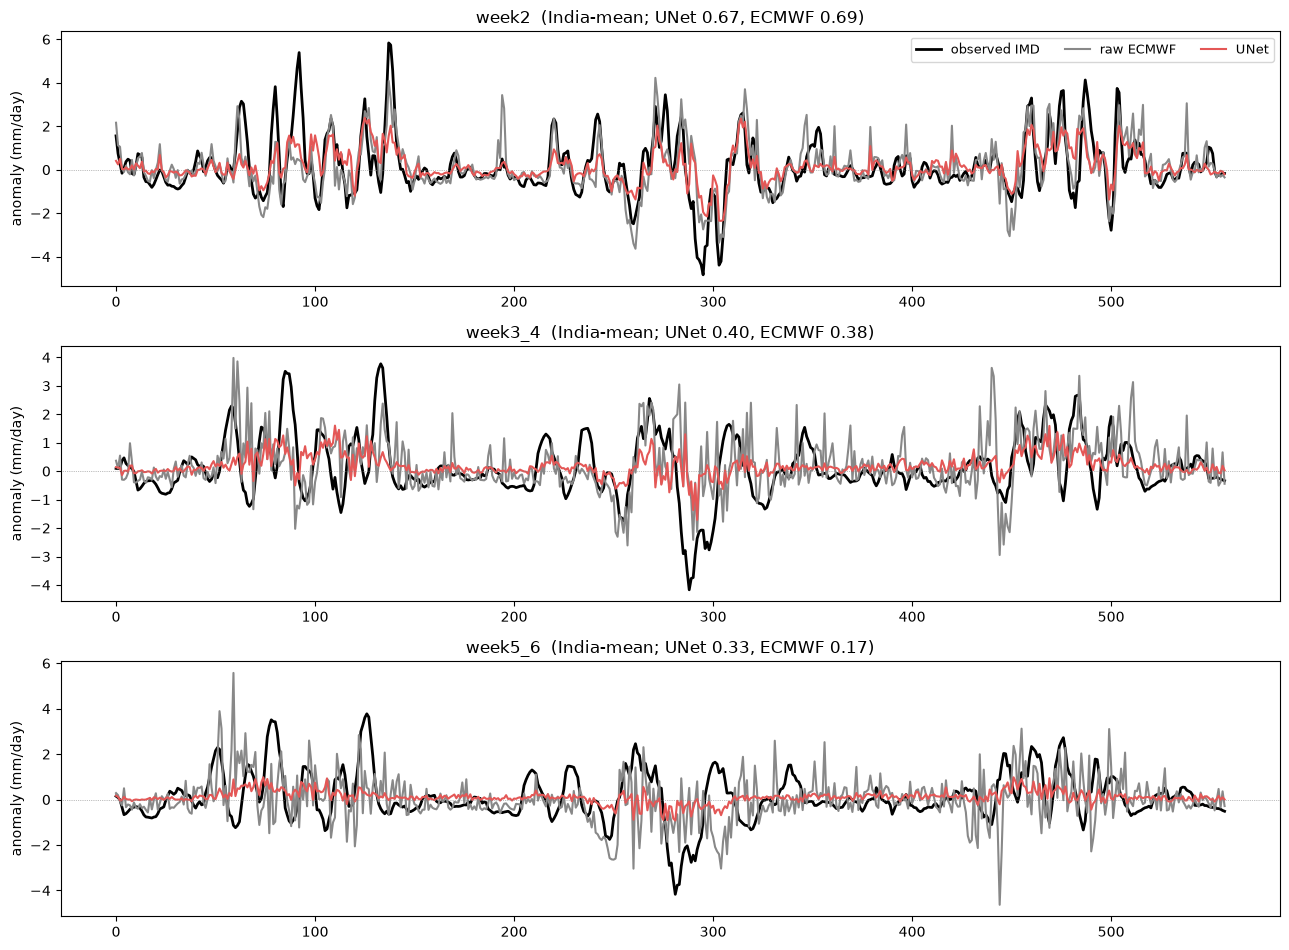

/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_69788/4130821505.py:28: RuntimeWarning: Mean of empty slice
  mf = np.nanmean(r_f, axis=0)
/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_69788/4130821505.py:29: RuntimeWarning: Mean of empty slice
  mc = np.nanmean(r_c, axis=0)
/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_69788/3173173865.py:55: RuntimeWarning: Mean of empty slice
  pw = np.nanmean(np.where(fin[s], probs[s][:, 2], np.nan), axis=0)


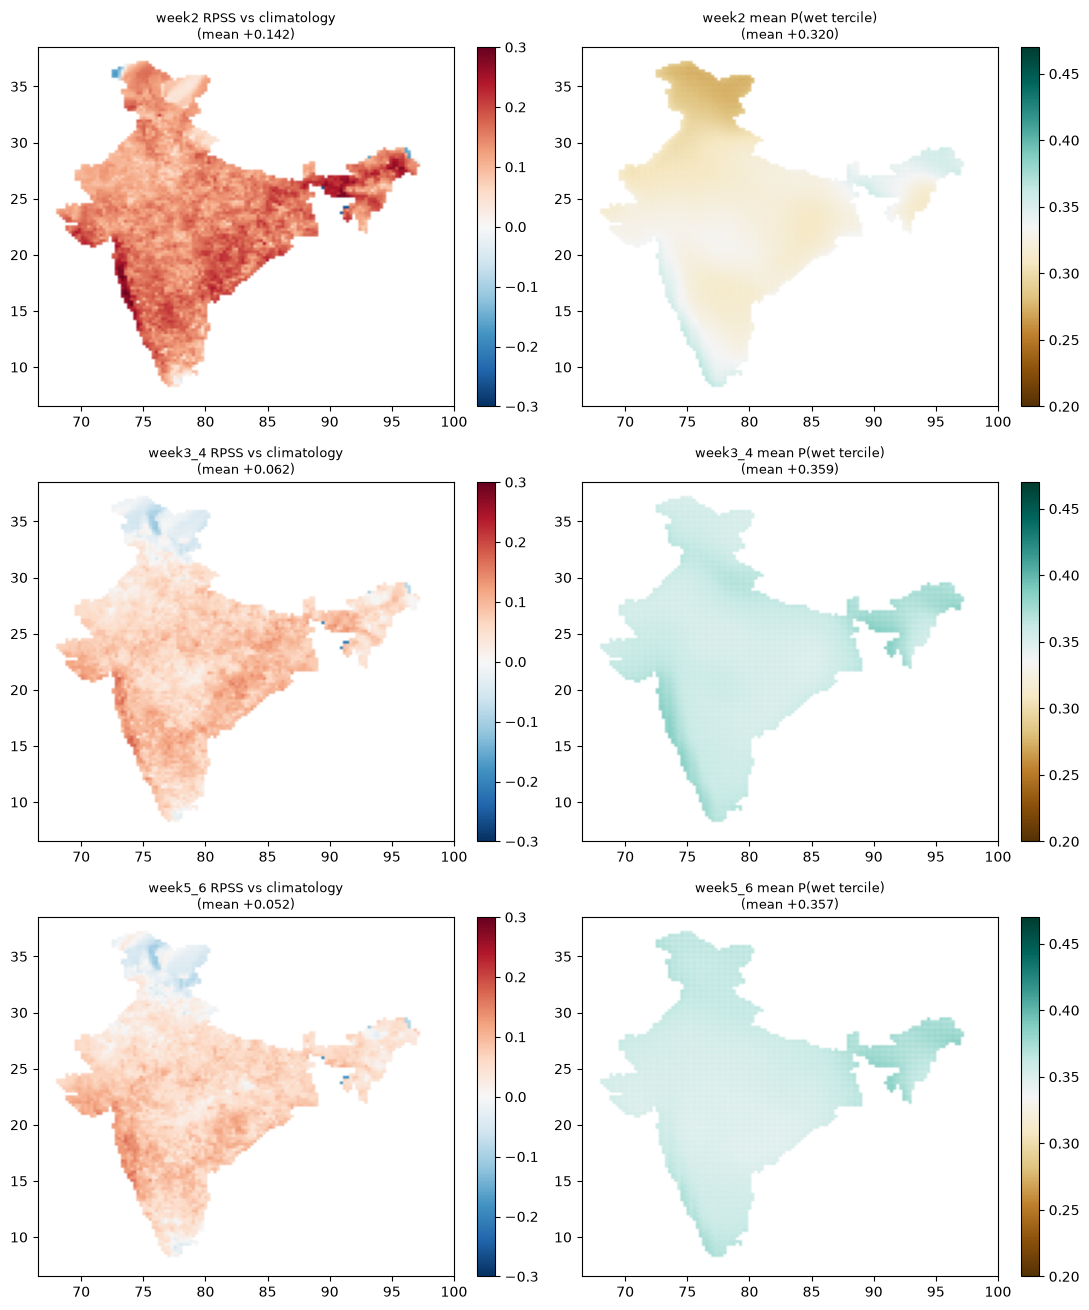

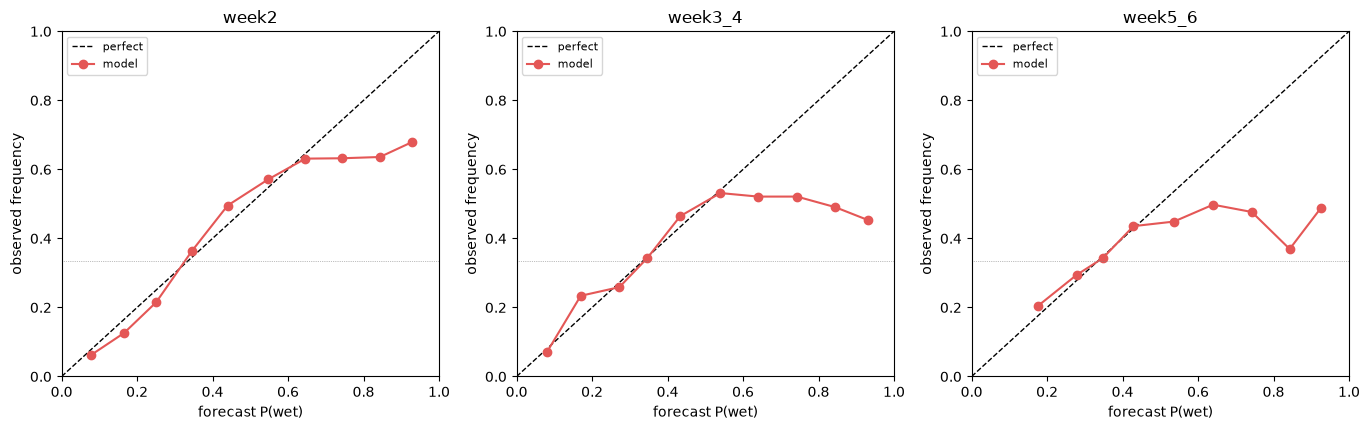

/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_69788/3173173865.py:95: RuntimeWarning: Mean of empty slice
  pm = np.nanmean(np.where(f_, p_, np.nan), 0)
/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_69788/3173173865.py:96: RuntimeWarning: Mean of empty slice
  tm = np.nanmean(np.where(f_, t_, np.nan), 0)


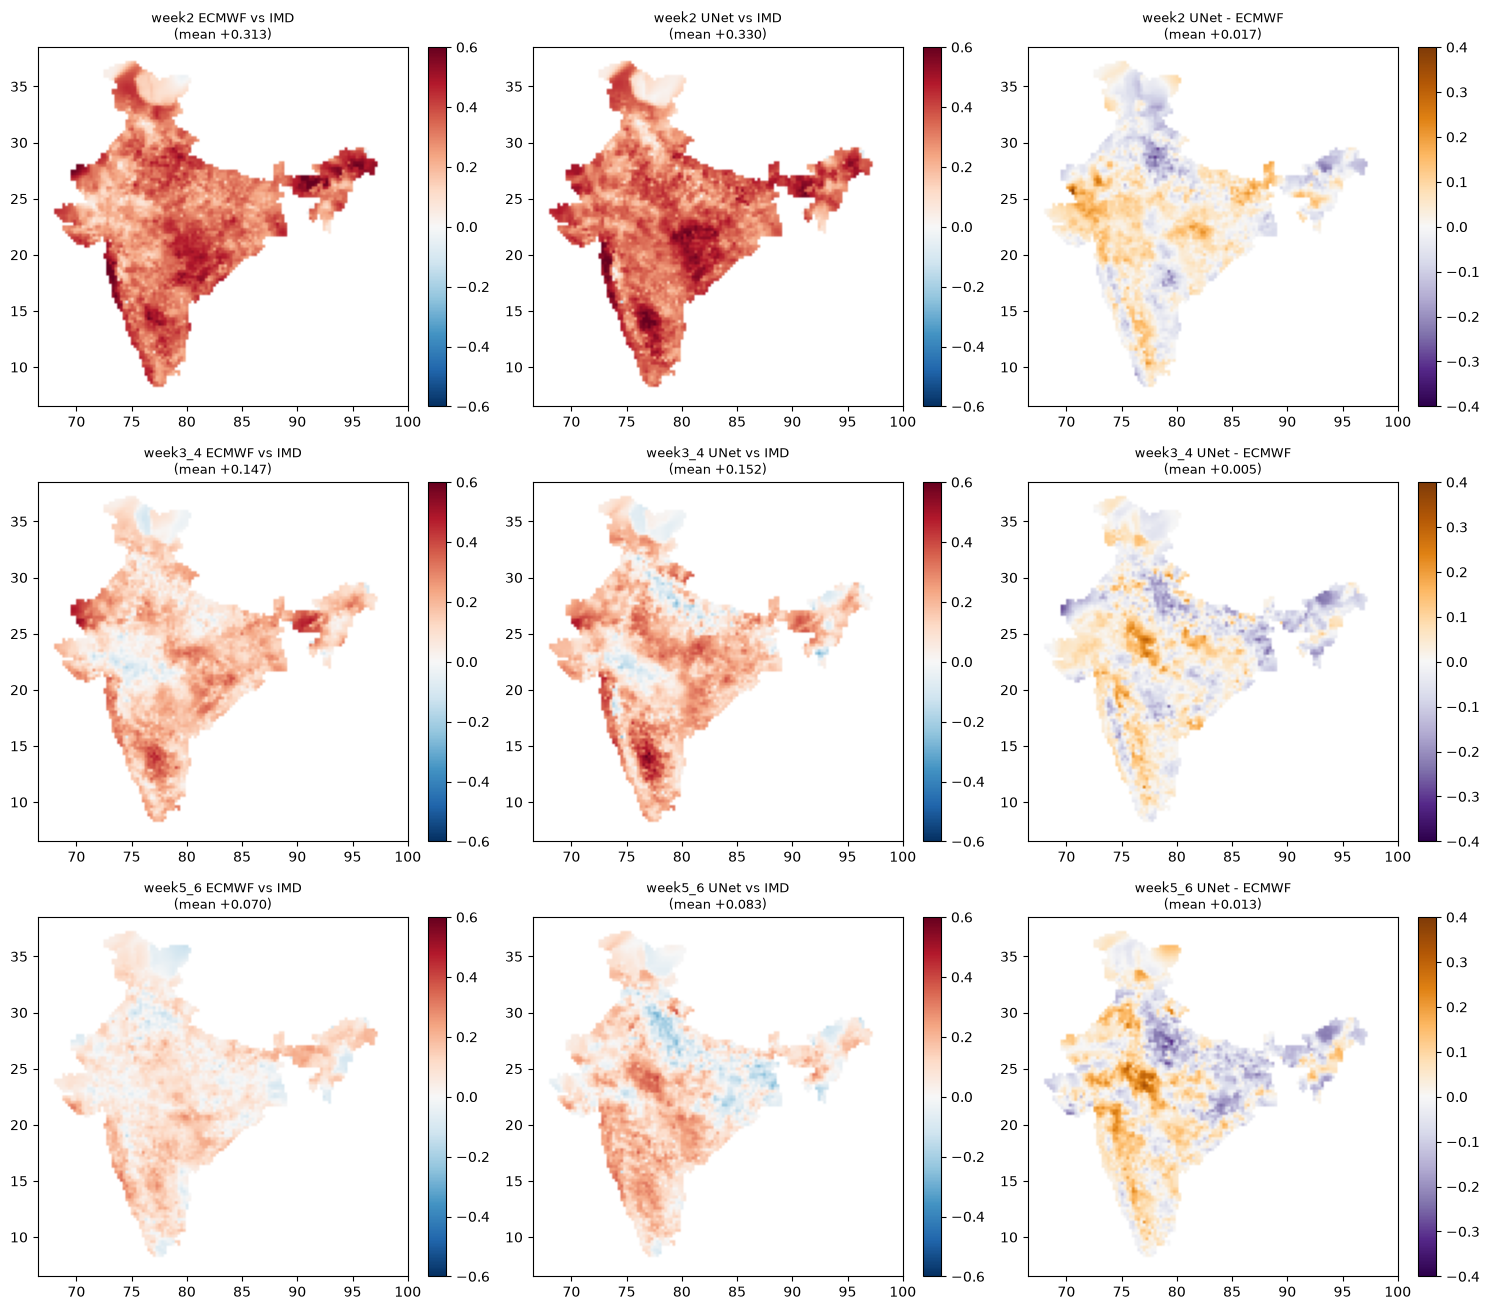

-> threeline_prob_t_d.png, rpss_maps_prob_t_d.png, reliability_prob_t_d.png, corr_maps_prob_t_d.png/.nc/.npz


In [14]:
# %%
# ============ CELL 11: PLOTS ============
# Reads the saved _pred.npz — no model rebuild, no inference.
 
def plot_all(pred_npz=None, tag=None):
    import matplotlib.pyplot as plt
    import xarray as xr
    pred_npz = pred_npz or OUT_MAPS.replace(".nc", "_pred.npz")
    tag = tag or TAG
 
    pr = np.load(pred_npz)
    probs = pr["probs"] if pr["probs"].size else None
    det = pr["det"] if pr["det"].size else None
    obs_a, obs_c, wid_te = pr["obs_anom"], pr["obs_cls"], pr["wid"]
 
    # raw ECMWF tp -> fine grid -> anomaly (own climatology, so units cancel)
    varsA = [str(v) for v in _m["varsA"]]
    fit_i = ~is_test
    tp_f = xr.DataArray(XA[:, varsA.index("total_precipitation")],
                        dims=("s", "lat", "lon"),
                        coords={"lat": clatA, "lon": clonA}
                        ).interp(lat=flat_lat, lon=flat_lon).values.astype(DTYPE)
    ecm_a = (tp_f - _clim_grid(tp_f[fit_i], doy[fit_i], CLIM_WINDOW_DAYS)[doy - 1])[is_test]
 
    m3 = mask[None]
    fin = np.isfinite(np.asarray(y)[is_test]) & m3
    ext = [flat_lon[0], flat_lon[-1], flat_lat[0], flat_lat[-1]]
 
    # ---------- 1. deterministic three-line ----------
    if det is not None:
        im = lambda a: np.nansum(np.where(m3, a, np.nan), axis=(1, 2)) / m3.sum()
        io, ie, iu = im(obs_a), im(ecm_a), im(det)
        fig, axes = plt.subplots(N_WIN, 1, figsize=(13, 3.2 * N_WIN))
        for w, ax in enumerate(np.atleast_1d(axes)):
            s = wid_te == w
            tt = np.arange(s.sum())
            ax.plot(tt, io[s], "-", color="k", lw=2, label="observed IMD")
            ax.plot(tt, ie[s], "-", color="#888", lw=1.5, label="raw ECMWF")
            ax.plot(tt, iu[s], "-", color="#E45756", lw=1.5, label="UNet")
            ax.axhline(0, color="gray", lw=.5, ls=":")
            ru = np.corrcoef(iu[s], io[s])[0, 1]
            re = np.corrcoef(ie[s], io[s])[0, 1]
            ax.set_title(f"{window_names[w]}  (India-mean; UNet {ru:.2f}, ECMWF {re:.2f})")
            ax.set_ylabel("anomaly (mm/day)")
            if w == 0:
                ax.legend(ncol=3, fontsize=9)
        fig.tight_layout(); fig.savefig(f"threeline_{tag}.png", dpi=140); plt.show()
 
    # ---------- 2. RPSS maps + "chance of wet" ----------
    if probs is not None:
        fig, axes = plt.subplots(N_WIN, 2, figsize=(11, 4.4 * N_WIN))
        for w in range(N_WIN):
            s = wid_te == w
            r = rpss_map(probs[s], obs_c[s], fin[s]); r[~mask] = np.nan
            pw = np.nanmean(np.where(fin[s], probs[s][:, 2], np.nan), axis=0)
            pw[~mask] = np.nan
            for c, (arr, ttl, cm, lo, hi) in enumerate([
                    (r, "RPSS vs climatology", "RdBu_r", -0.3, 0.3),
                    (pw, "mean P(wet tercile)", "BrBG", 0.2, 0.47)]):
                ax = np.atleast_2d(axes)[w, c]
                i_ = ax.imshow(arr, cmap=cm, origin="lower", extent=ext,
                               aspect="auto", vmin=lo, vmax=hi)
                fig.colorbar(i_, ax=ax, fraction=.046)
                ax.set_title(f"{window_names[w]} {ttl}\n"
                             f"(mean {np.nanmean(arr[mask]):+.3f})", fontsize=9)
        fig.tight_layout(); fig.savefig(f"rpss_maps_{tag}.png", dpi=130); plt.show()
 
        # ---------- 3. reliability diagram ----------
        # Of the times the model said "X% chance of wet", how often was it wet?
        # On the diagonal = calibrated. Below = overconfident.
        fig, axes = plt.subplots(1, N_WIN, figsize=(4.6 * N_WIN, 4.4))
        bins = np.linspace(0, 1, 11)
        for w, ax in enumerate(np.atleast_1d(axes)):
            s = wid_te == w
            p_wet = probs[s][:, 2][fin[s]]
            o_wet = (obs_c[s] == 2)[fin[s]].astype(float)
            xs, ys, ns = [], [], []
            for b in range(len(bins) - 1):
                m_ = (p_wet >= bins[b]) & (p_wet < bins[b + 1])
                if m_.sum() > 50:
                    xs.append(p_wet[m_].mean()); ys.append(o_wet[m_].mean())
                    ns.append(int(m_.sum()))
            ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
            ax.plot(xs, ys, "o-", color="#E45756", label="model")
            ax.axhline(1 / 3, color="gray", lw=.5, ls=":")
            ax.set_xlim(0, 1); ax.set_ylim(0, 1)
            ax.set_xlabel("forecast P(wet)"); ax.set_ylabel("observed frequency")
            ax.set_title(window_names[w]); ax.legend(fontsize=8)
        fig.tight_layout(); fig.savefig(f"reliability_{tag}.png", dpi=130); plt.show()
 
    # ---------- 4. deterministic correlation maps ----------
    if det is not None:
        def cmap_(p_, t_, f_):
            with np.errstate(invalid="ignore", divide="ignore"):
                pm = np.nanmean(np.where(f_, p_, np.nan), 0)
                tm = np.nanmean(np.where(f_, t_, np.nan), 0)
                num = np.nansum(np.where(f_, (p_ - pm) * (t_ - tm), np.nan), 0)
                den = np.sqrt(np.nansum(np.where(f_, (p_ - pm) ** 2, np.nan), 0)
                              * np.nansum(np.where(f_, (t_ - tm) ** 2, np.nan), 0))
                return np.where(den > 0, num / den, np.nan)
 
        maps = {}
        fig, axes = plt.subplots(N_WIN, 3, figsize=(15, 4.4 * N_WIN))
        for w in range(N_WIN):
            s = wid_te == w
            ce = cmap_(ecm_a[s], obs_a[s], fin[s]); ce[~mask] = np.nan
            cu = cmap_(det[s], obs_a[s], fin[s]); cu[~mask] = np.nan
            wn = window_names[w]
            maps[f"{wn}_corr_ecmwf"] = ce
            maps[f"{wn}_corr_unet"] = cu
            maps[f"{wn}_corr_diff"] = cu - ce
            for c, (arr, ttl, cm, vr) in enumerate([
                    (ce, "ECMWF vs IMD", "RdBu_r", .6),
                    (cu, "UNet vs IMD", "RdBu_r", .6),
                    (cu - ce, "UNet - ECMWF", "PuOr_r", .4)]):
                ax = np.atleast_2d(axes)[w, c]
                i_ = ax.imshow(arr, cmap=cm, origin="lower", extent=ext,
                               aspect="auto", vmin=-vr, vmax=vr)
                fig.colorbar(i_, ax=ax, fraction=.046)
                ax.set_title(f"{wn} {ttl}\n(mean {np.nanmean(arr[mask]):+.3f})",
                             fontsize=9)
        fig.tight_layout(); fig.savefig(f"corr_maps_{tag}.png", dpi=130); plt.show()
        xr.Dataset({k: (("lat", "lon"), v) for k, v in maps.items()},
                   coords={"lat": flat_lat, "lon": flat_lon}
                   ).to_netcdf(f"corr_maps_{tag}.nc")
        np.savez_compressed(f"corr_maps_{tag}.npz", lat=flat_lat, lon=flat_lon,
                            mask=mask, **maps)
 
    print(f"-> threeline_{tag}.png, rpss_maps_{tag}.png, "
          f"reliability_{tag}.png, corr_maps_{tag}.png/.nc/.npz")
 
 
plot_all()

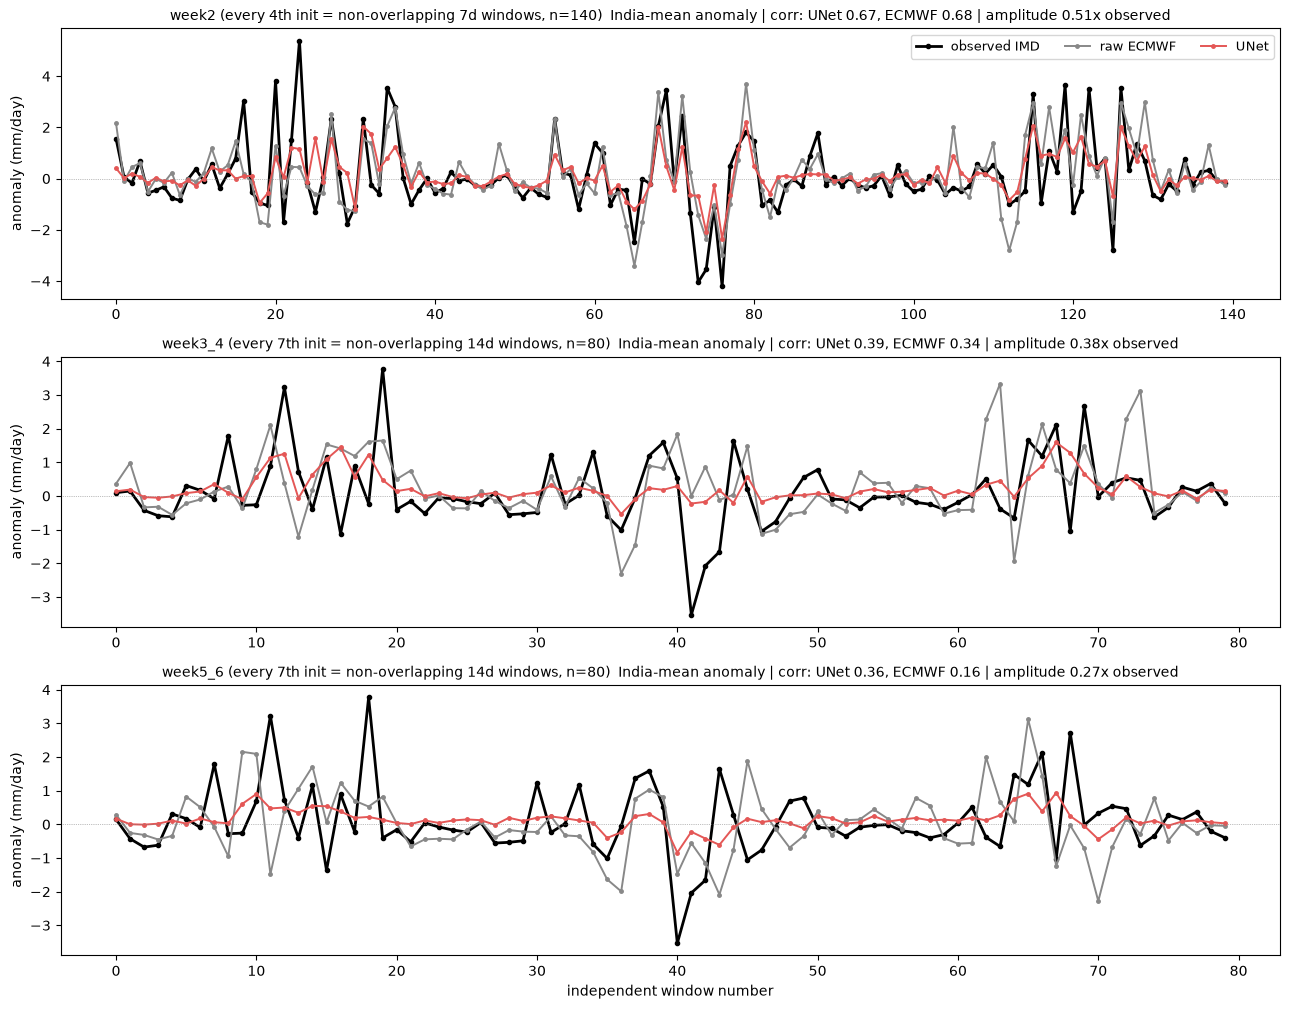

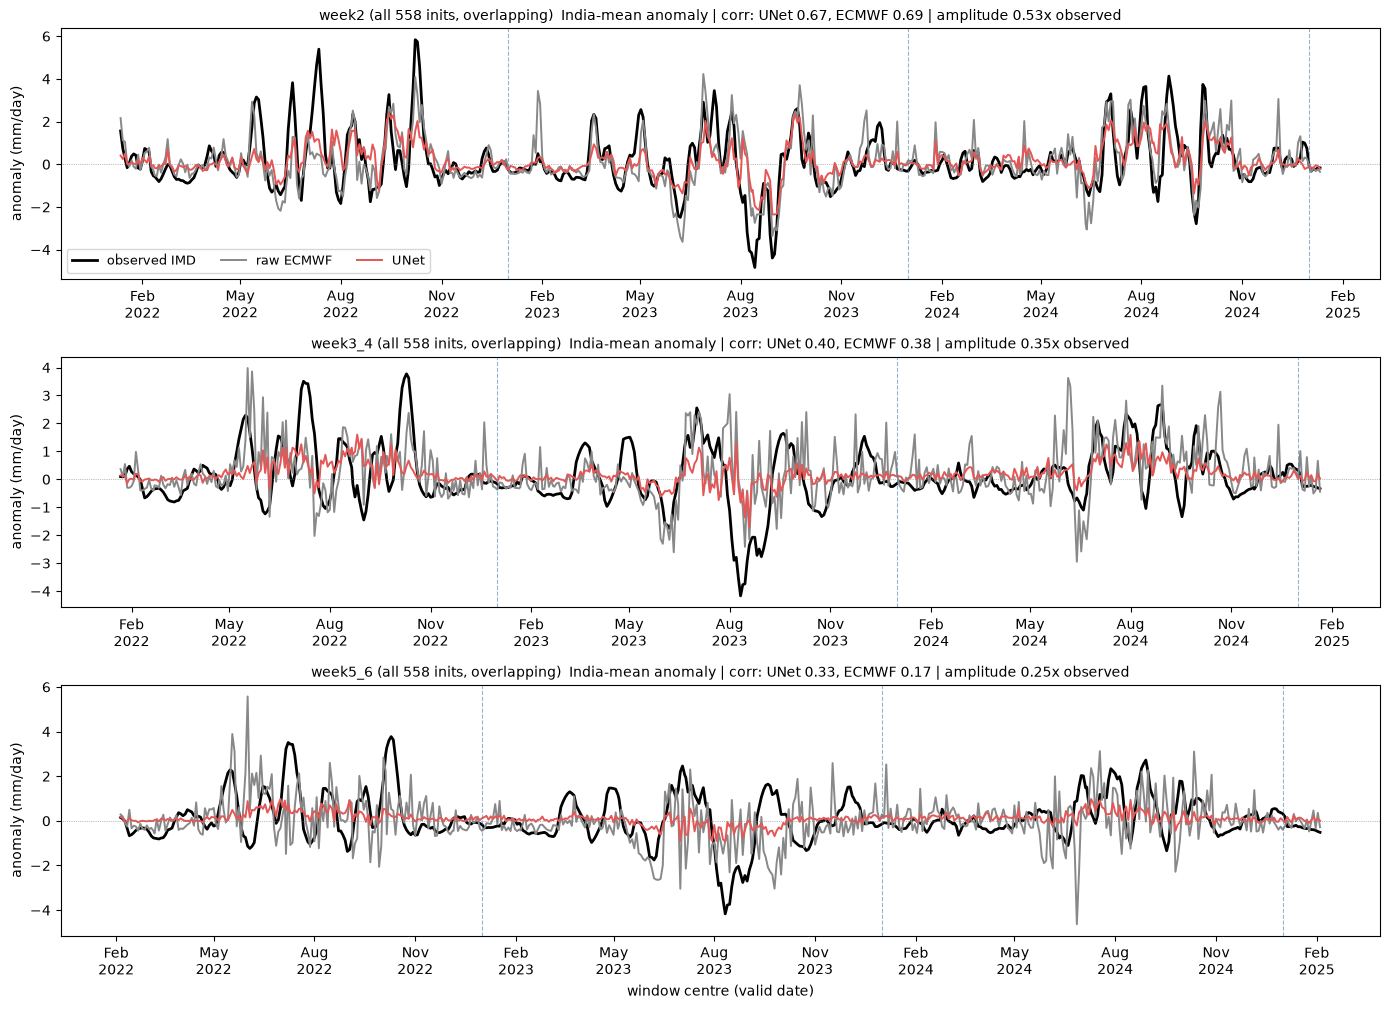

init cadence: 2d
-> threeline_strided_prob_t_d.png, threeline_dates_prob_t_d.png


In [17]:
# %%
# ============ CELL 12: HONEST TIME-AXIS PLOTS ============
# Two fixes for the threeline figure in cell 11, which plots all 558 test
# inits against a bare index.
#
# THE PROBLEM: consecutive inits overlap heavily. An init on 1 Jul and one on
# 3 Jul both target ~16-29 Jul for the week3_4 window — 13 of 14 days shared.
# Scoring is unaffected (each is a separate forecast, correctly scored), but
# VISUALLY one bad fortnight appears as ~20 consecutive failures, and the
# x-axis tells you nothing about when anything happened.
#
#   PLOT A (strided)    keep only non-overlapping windows, so each point is an
#                       independent fortnight. ~80 points instead of 558.
#   PLOT B (valid date) real calendar axis, year boundaries marked. Shows the
#                       overlap as overlap instead of hiding it, and lets you
#                       locate each excursion in an actual monsoon season.
#
# NEITHER CHANGES THE UNDERSHOOT. The red line stays flatter than the black by
# the same ratio: the amplitude gap is per-window and is not created by
# overlap. Window-averaging is applied to BOTH sides equally, so it cannot
# produce std_ratio ~0.27. That number is MSE optimality — at ACC ~0.24 the
# squared-error-minimising amplitude IS ~0.24 of observed. Subsampling makes
# the PLOT honest; it does not make the model less hedged.


def _valid_dates():
    """Reconstruct each sample's window-centre date from (year, doy) in meta.

    `year` is the INIT year and `doy` is the WINDOW-CENTRE day of year, so a
    late-December init whose window centre falls in January carries the
    previous year's label. Detect that and roll forward, else the point lands
    a year early on the axis.
    """
    offsets = np.array([(lo + hi) // 2 for _, lo, hi in WINDOWS])
    off = offsets[wid]
    yr = year.copy()
    wrapped = doy <= off                    # centre rolled into the next year
    yr = yr + wrapped.astype(int)
    base = np.array([np.datetime64(f"{int(v)}-01-01") for v in yr])
    return base + (doy - 1).astype("timedelta64[D]")


def _init_cadence_days():
    """Median spacing between consecutive inits, from the reconstructed dates."""
    d = np.sort(np.unique(_valid_dates()[wid == 0]))
    if len(d) < 3:
        return 2
    gaps = np.diff(d).astype("timedelta64[D]").astype(int)
    return max(int(np.median(gaps[gaps > 0])), 1)


def plot_time(pred_npz=None, tag=None, mode="both"):
    """mode: 'strided' | 'dates' | 'both'."""
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates

    pred_npz = pred_npz or OUT_MAPS.replace(".nc", "_pred.npz")
    tag = tag or TAG
    pr = np.load(pred_npz)
    det = pr["det"] if pr["det"].size else None
    if det is None:
        print("no deterministic head in this run — nothing to plot")
        return
    obs_a, wid_te = pr["obs_anom"], pr["wid"]

    # raw ECMWF tp anomaly on the fine grid (own climatology, units cancel)
    import xarray as xr
    varsA = [str(v) for v in _m["varsA"]]
    fit_i = ~is_test
    tp_f = xr.DataArray(XA[:, varsA.index("total_precipitation")],
                        dims=("s", "lat", "lon"),
                        coords={"lat": clatA, "lon": clonA}
                        ).interp(lat=flat_lat, lon=flat_lon).values.astype(DTYPE)
    ecm_a = (tp_f - _clim_grid(tp_f[fit_i], doy[fit_i],
                               CLIM_WINDOW_DAYS)[doy - 1])[is_test]

    m3 = mask[None]
    im = lambda a: np.nansum(np.where(m3, a, np.nan), axis=(1, 2)) / m3.sum()
    io, ie, iu = im(obs_a), im(ecm_a), im(det)

    dates_te = _valid_dates()[is_test]
    cadence = _init_cadence_days()

    def _panel(ax, sel, xvals, title_extra="", date_axis=False):
        ax.plot(xvals, io[sel], "-o" if not date_axis else "-",
                color="k", lw=2, ms=3, label="observed IMD")
        ax.plot(xvals, ie[sel], "-o" if not date_axis else "-",
                color="#888", lw=1.4, ms=2.5, label="raw ECMWF")
        ax.plot(xvals, iu[sel], "-o" if not date_axis else "-",
                color="#E45756", lw=1.4, ms=2.5, label="UNet")
        ax.axhline(0, color="gray", lw=.5, ls=":")
        ru = np.corrcoef(iu[sel], io[sel])[0, 1]
        re = np.corrcoef(ie[sel], io[sel])[0, 1]
        sr = float(np.std(iu[sel]) / np.std(io[sel]))
        ax.set_title(f"{title_extra}  India-mean anomaly | "
                     f"corr: UNet {ru:.2f}, ECMWF {re:.2f} | "
                     f"amplitude {sr:.2f}x observed", fontsize=10)
        ax.set_ylabel("anomaly (mm/day)")

    # ---------- PLOT A: non-overlapping windows ----------
    if mode in ("strided", "both"):
        fig, axes = plt.subplots(N_WIN, 1, figsize=(13, 3.4 * N_WIN))
        for w, ax in enumerate(np.atleast_1d(axes)):
            _, lo, hi = WINDOWS[w]
            win_len = hi - lo + 1
            stride = max(int(round(win_len / cadence)), 1)
            idx = np.where(wid_te == w)[0][::stride]
            _panel(ax, idx, np.arange(len(idx)),
                   f"{window_names[w]} (every {stride}th init = "
                   f"non-overlapping {win_len}d windows, n={len(idx)})")
            if w == 0:
                ax.legend(ncol=3, fontsize=9)
        axes_last = np.atleast_1d(axes)[-1]
        axes_last.set_xlabel("independent window number")
        fig.tight_layout()
        fig.savefig(f"threeline_strided_{tag}.png", dpi=140)
        plt.show()

    # ---------- PLOT B: real calendar axis ----------
    if mode in ("dates", "both"):
        fig, axes = plt.subplots(N_WIN, 1, figsize=(14, 3.4 * N_WIN))
        for w, ax in enumerate(np.atleast_1d(axes)):
            sel = np.where(wid_te == w)[0]
            order = np.argsort(dates_te[sel])
            sel = sel[order]
            _panel(ax, sel, dates_te[sel],
                   f"{window_names[w]} (all {len(sel)} inits, overlapping)",
                   date_axis=True)
            # mark year boundaries so the seasons are locatable
            yrs = np.unique(dates_te[sel].astype("datetime64[Y]"))
            for yb in yrs[1:]:
                ax.axvline(yb.astype("datetime64[D]"), color="steelblue",
                           lw=.8, ls="--", alpha=.6)
            ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
            if w == 0:
                ax.legend(ncol=3, fontsize=9)
        np.atleast_1d(axes)[-1].set_xlabel("window centre (valid date)")
        fig.tight_layout()
        fig.savefig(f"threeline_dates_{tag}.png", dpi=140)
        plt.show()

    print(f"init cadence: {cadence}d")
    print(f"-> threeline_strided_{tag}.png, threeline_dates_{tag}.png")


plot_time()